In [35]:
%matplotlib inline
import numpy as np
import os
import pandas as pd
import glob
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
import japanize_matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc


In [36]:
tasks = ["task1","task2"]
Days = [14, 17, 20, 24, 27, 31, 34, 38]

"""
def load_data(Day):
    if Day == 38:
        df_feature= pd.read_csv("../data/fftfeature/feature38.csv")
    elif Day == 34:
        df_feature= pd.read_csv("../data/fftfeature/feature34.csv")
    elif Day == 31:
        df_feature= pd.read_csv("../data/fftfeature/feature31.csv")
    elif Day == 27:
        df_feature= pd.read_csv("../data/fftfeature/feature27.csv")
    elif Day == 24:
        df_feature= pd.read_csv("../data/fftfeature/feature24.csv")
    elif Day == 20:
        df_feature= pd.read_csv("../data/fftfeature/feature20.csv")
    elif Day == 17:
        df_feature= pd.read_csv("../data/fftfeature/feature17.csv")
    elif Day == 14:
        df_feature= pd.read_csv("../data/fftfeature/feature14.csv")

    return df_feature
"""

def extractX(df):
    X = df.iloc[:,1:87].values
    return X

def X2df(X,df):
    _df = pd.DataFrame(X)
    _df["batchno"]=df["batchno"].values
    _df["day"]=df["day"].values
    _df["score"]=df["score"].values
    _df["FLAG"]=df["FLAG"].values
    return _df

In [37]:
df = pd.read_csv("../data/featureD14_D38.csv")
X = extractX(df)

decomp = PCA()
X_decomp = decomp.fit_transform(X)

df_decomp = X2df(X_decomp, df)

## PCA

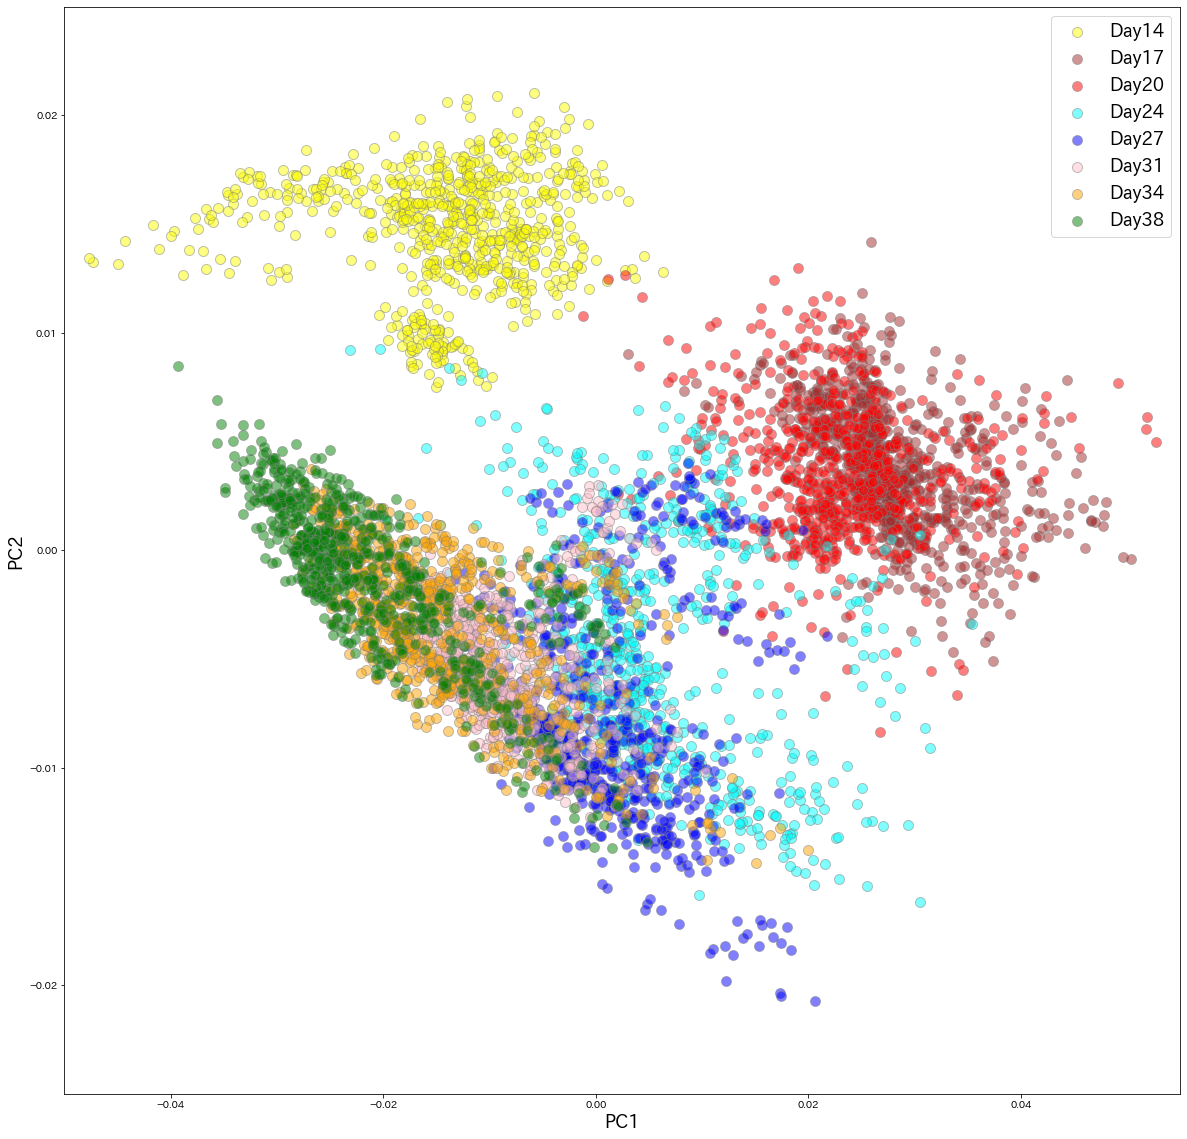

In [39]:
colorlist = ["green","orange","pink","blue","brown","red","grey","yellow"]
colorlist = ["yellow", "brown", "red", "cyan", "blue", "pink", "orange", "green"]

cmap = get_cmap("tab10")
plt.figure(figsize=(20,20))
for i,name in enumerate(Days):
    _df = df_decomp[df_decomp["day"]==name]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label="Day"+str(name), alpha=0.5, s = 100 , edgecolors= "gray")
#plt.title("PCA_日付")
plt.xlabel("PC1", fontsize=18)
plt.ylabel("PC2", fontsize=18)
plt.xlim(-0.05,0.055)
plt.ylim(-0.025,0.025)

plt.legend(fontsize=18)
plt.rc("svg", fonttype="none")
plt.savefig("pcaplot_all.svg")

plt.show()


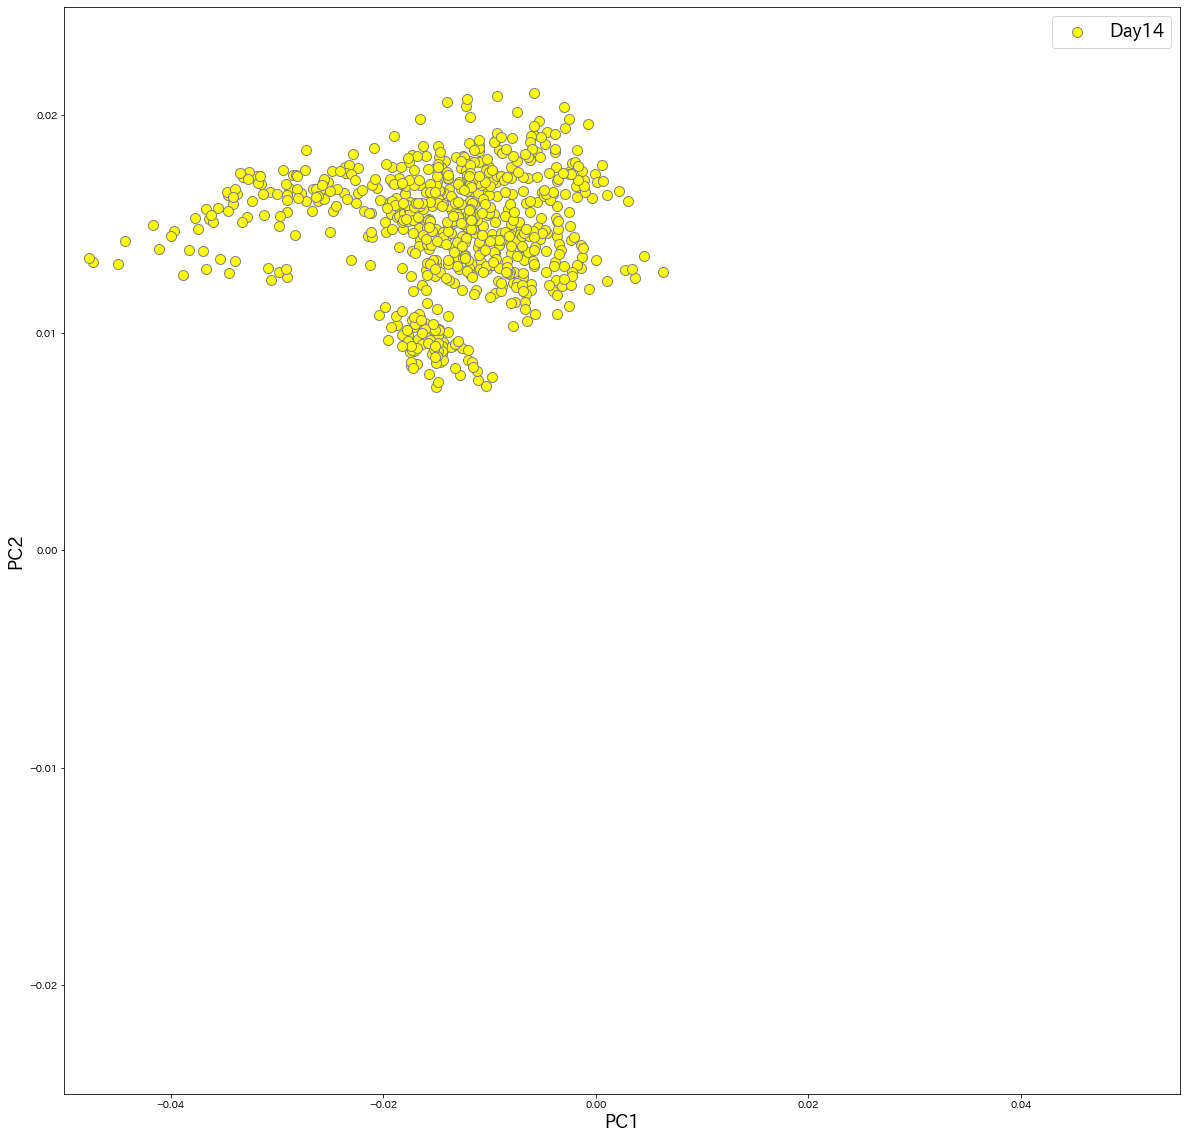

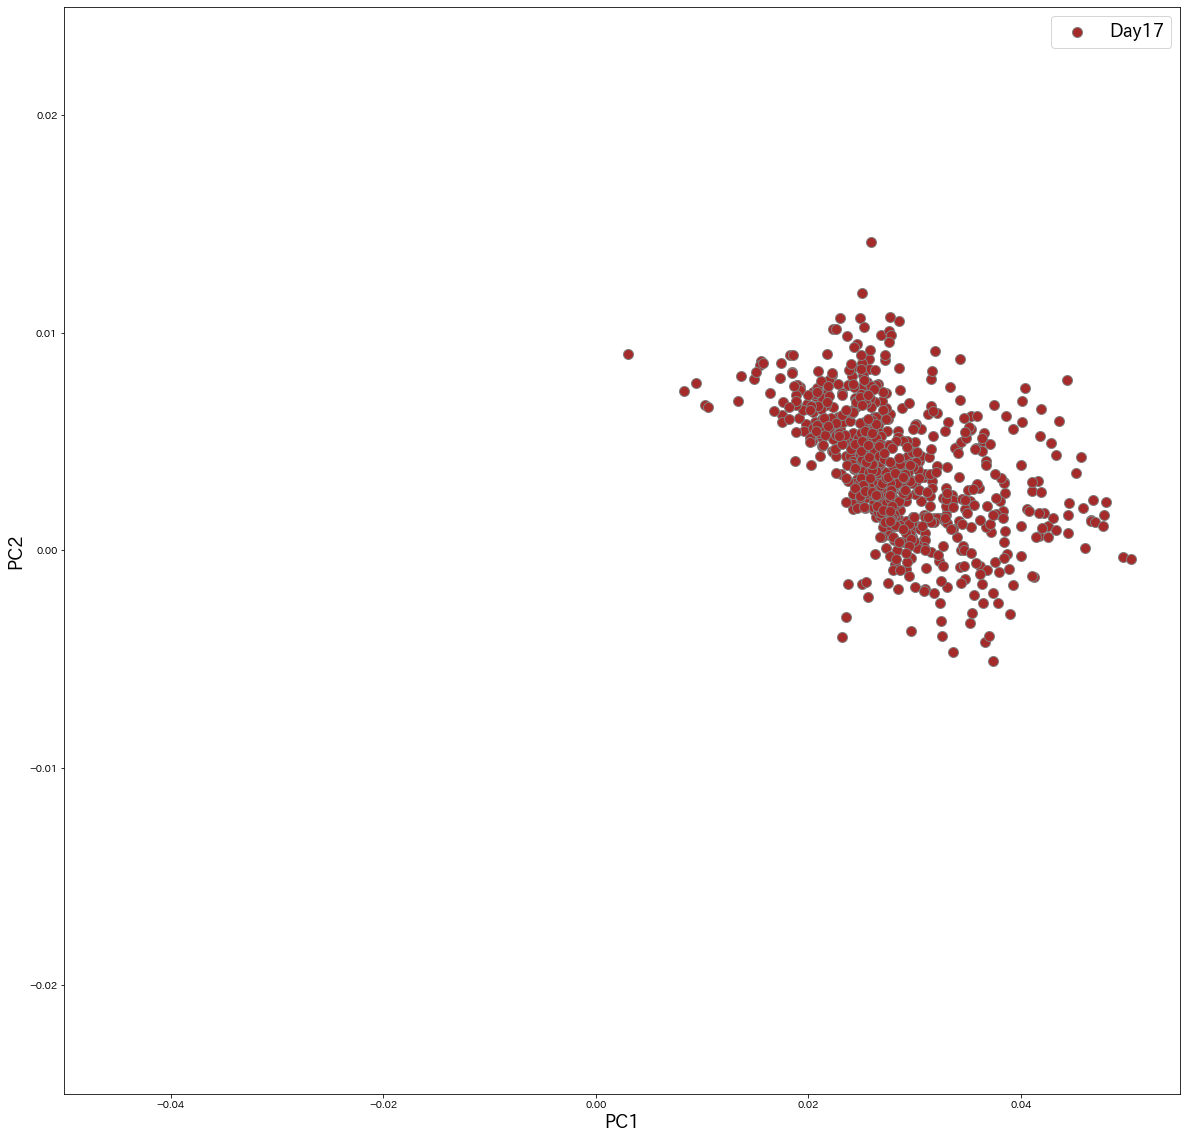

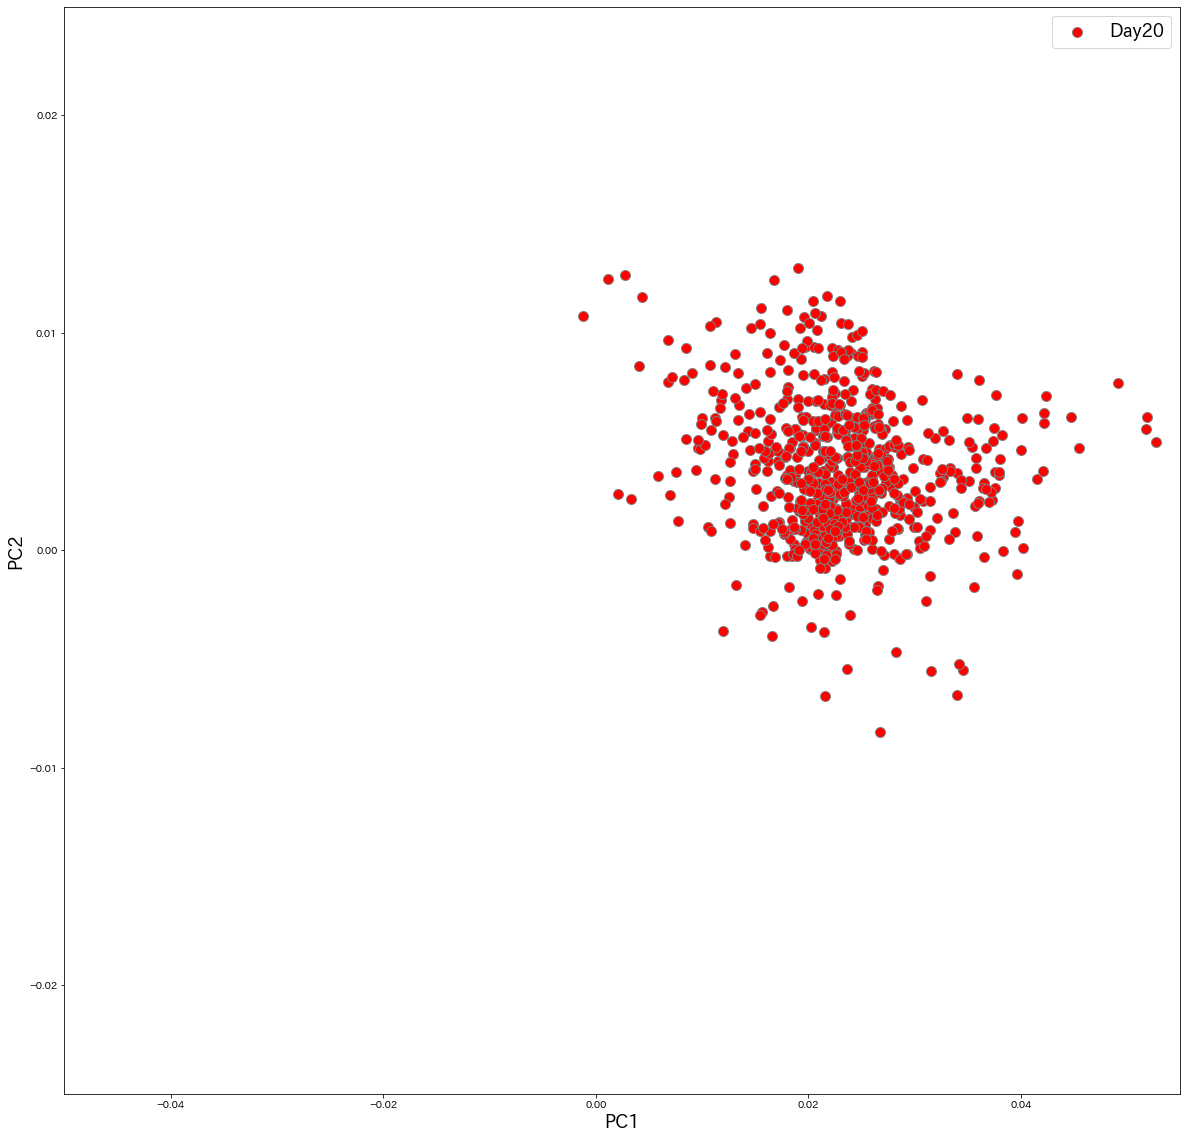

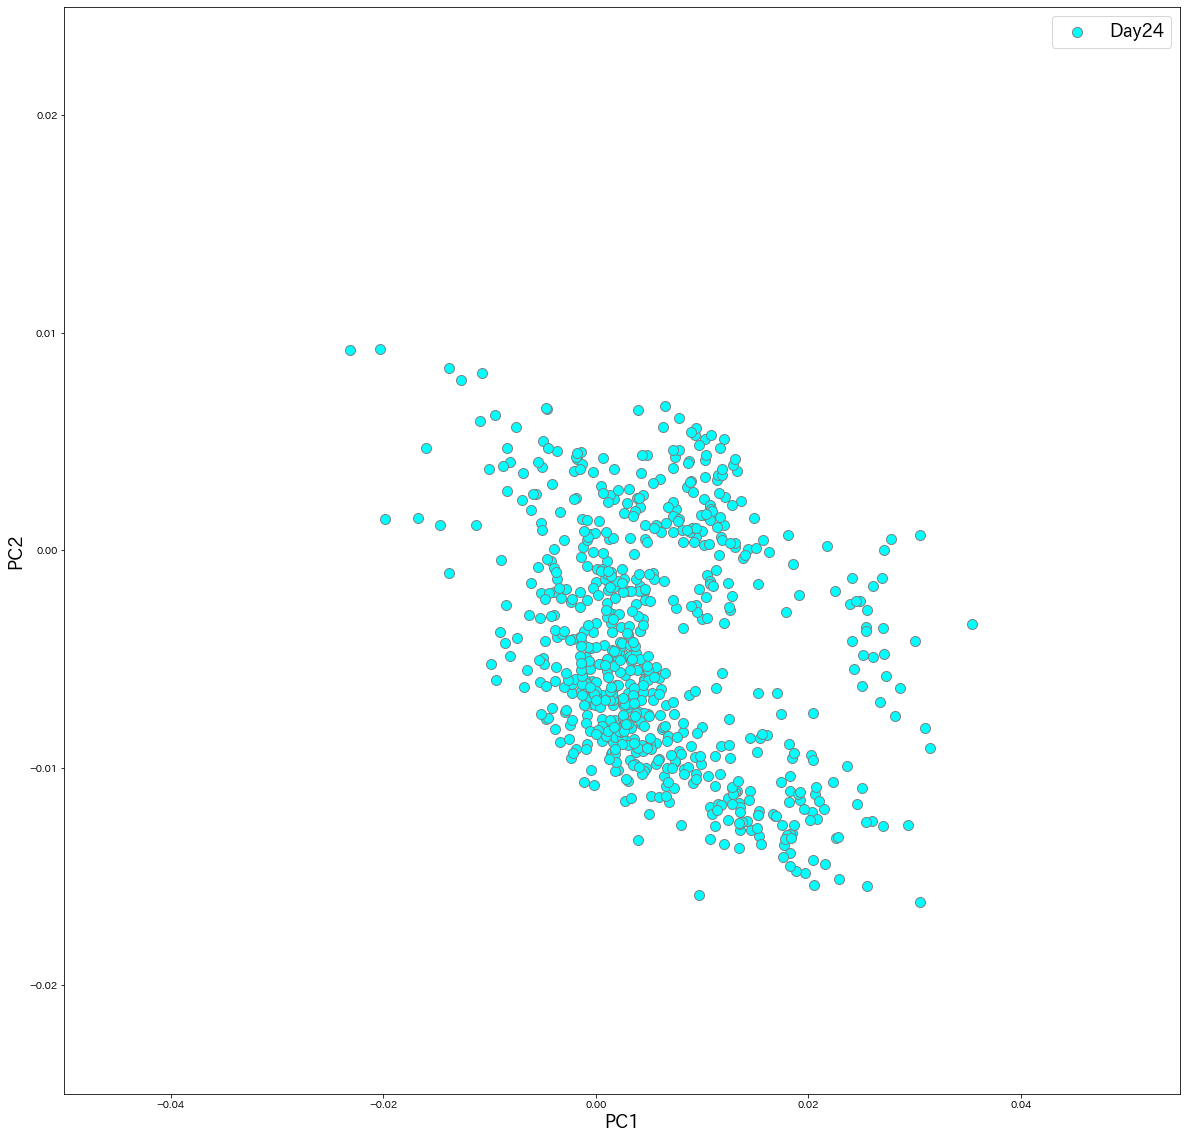

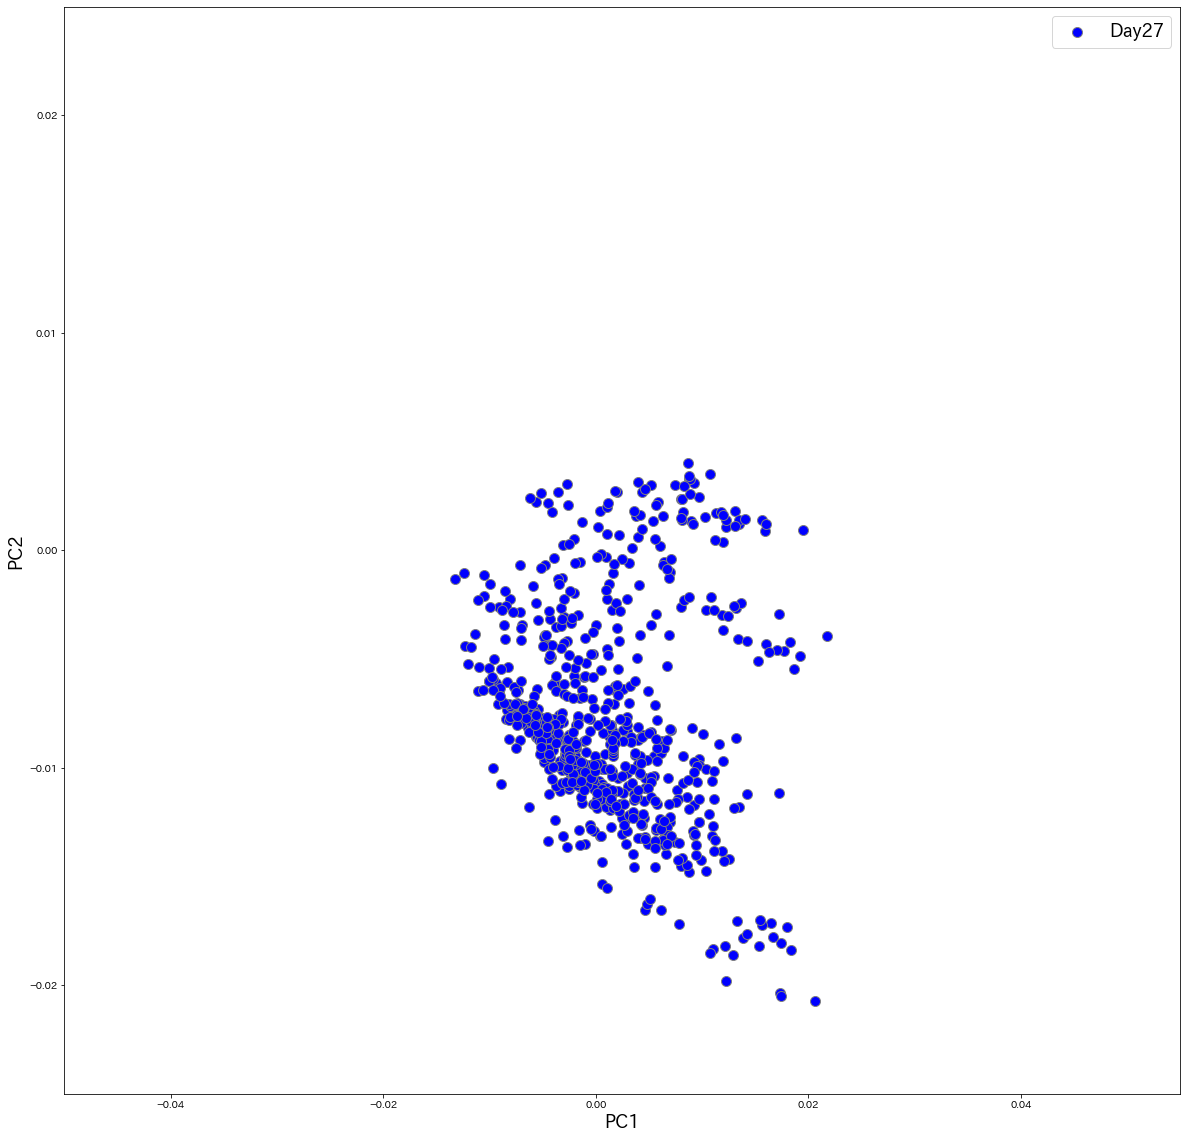

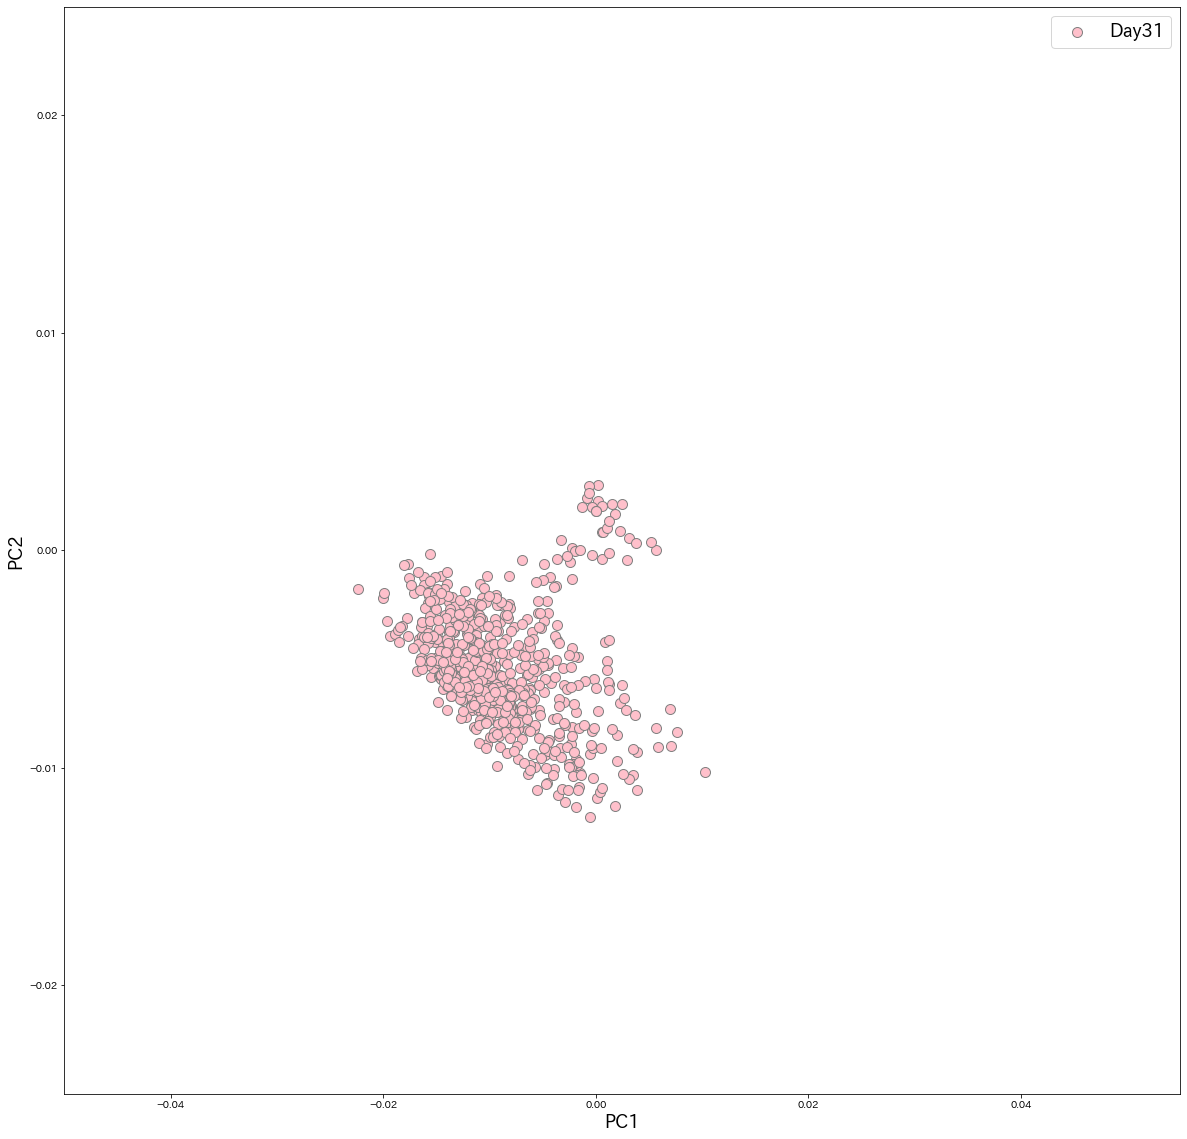

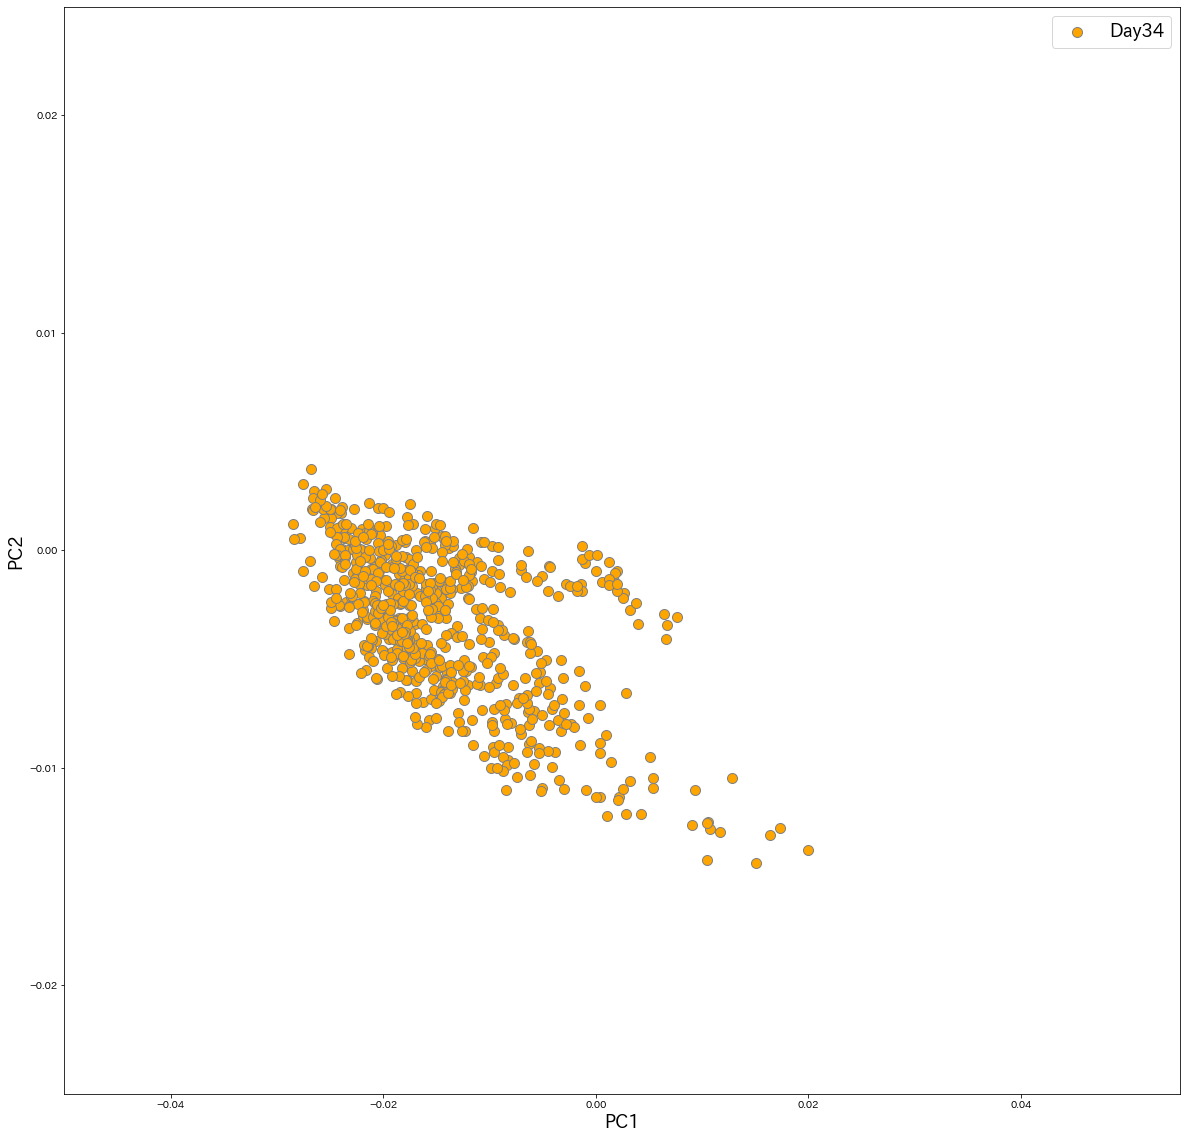

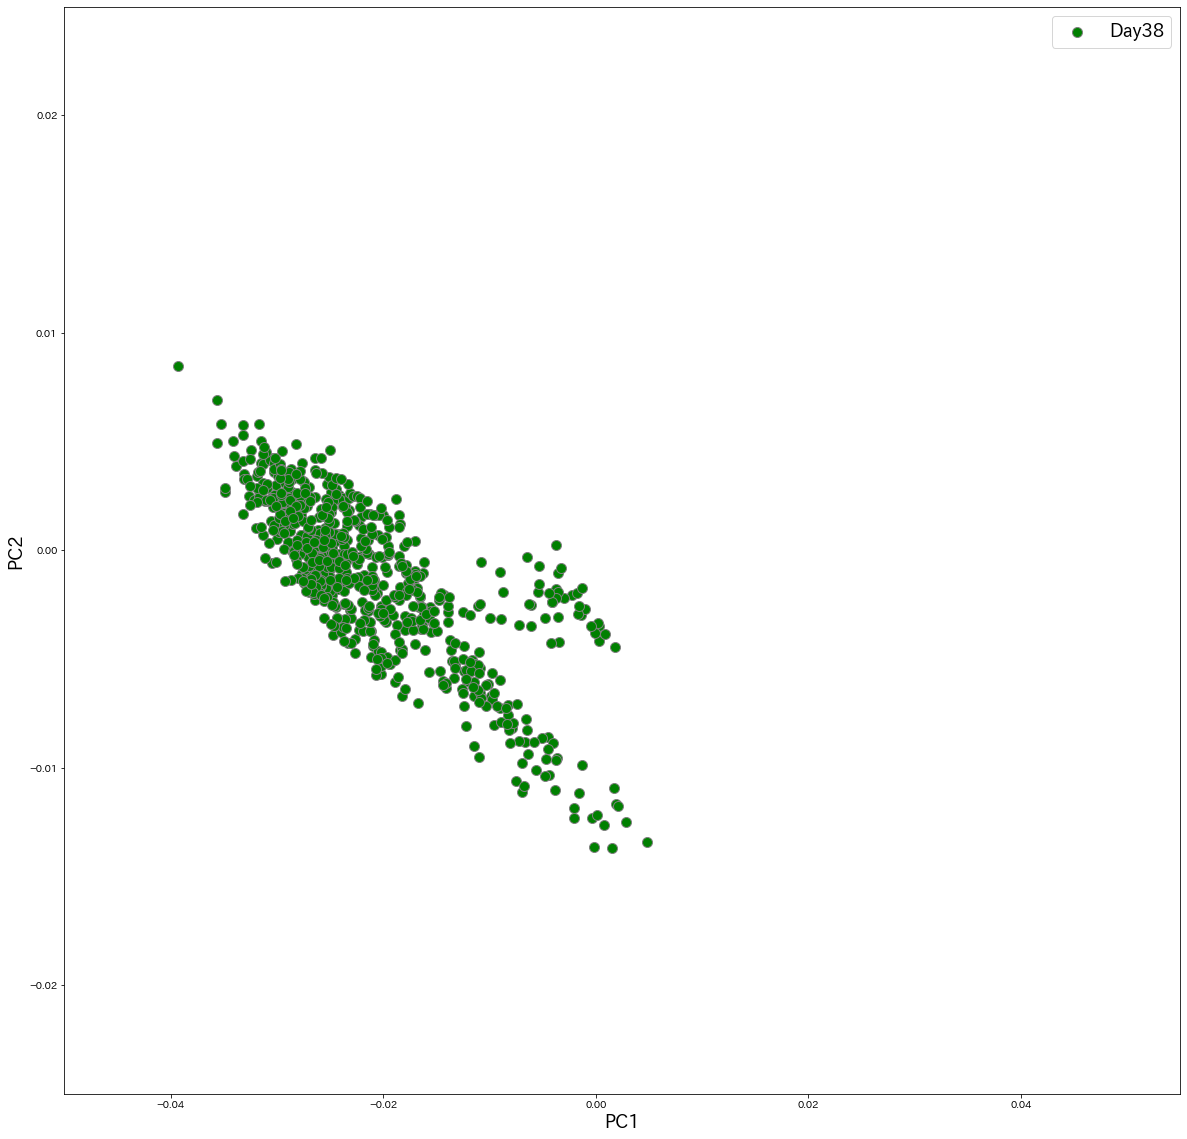

In [34]:
colorlist = ["yellow", "brown", "red", "cyan", "blue", "pink", "orange", "green"]

cmap = get_cmap("tab10")
for i,name in enumerate(Days):
    plt.figure(figsize=(20,20))
    _df = df_decomp[df_decomp["day"]==name]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label="Day"+str(name), alpha=1, s = 100 , edgecolors= "gray")
    #plt.title("PCA_日付")
    plt.xlabel("PC1", fontsize=18)
    plt.ylabel("PC2", fontsize=18)
    plt.xlim(-0.05,0.055)
    plt.ylim(-0.025,0.025)

    plt.legend(fontsize=18)
    plt.rc("svg", fonttype="none")
    plt.savefig("pcaplot_Day"+str(name)+".svg")

    plt.show()